# **Detection of feature extraction of electronic component**

In [ ]:
from google.colab.patches import cv2_imshow
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import cv2 as cv


from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_recall_curve, average_precision_score
import joblib

from google.colab import drive
drive.mount('/content/drive')

DATASET_DIR = '/content/drive/MyDrive/IMG PROJECT/project/data'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading dataset and preprocessing

In [ ]:

segmented_images = []
segmentation_masks = []
preprocessed = []
mean_intensities = []
labels = []
failed = 0
total = 0

for class_name in sorted(os.listdir(DATASET_DIR)):
    class_dir = os.path.join(DATASET_DIR, class_name)

    if not os.path.isdir(class_dir):
        continue

    for file_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, file_name)
        total += 1
        img = cv.imread(img_path)
        if img is None or img.shape[0]<50 or img.shape[1]<50:
            failed += 1
            continue

        img = cv.resize(img, (128, 128), interpolation=cv.INTER_AREA)


        hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
        v = hsv[:, :, 2]


        clahe = cv.createCLAHE(clipLimit=2.5, tileGridSize=(16, 16))
        v = clahe.apply(v)


        v = cv.bilateralFilter(v, d=5, sigmaColor=75, sigmaSpace=75)

        kernel_sharp = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
        v = cv.filter2D(v, -1, kernel_sharp)

        preprocessed.append(v)
        labels.append(class_name)








Segmentation

In [ ]:
for v in preprocessed:
        if np.mean(v) > 127:
            thresh_type = cv.THRESH_BINARY_INV
        else:
            thresh_type = cv.THRESH_BINARY

        _, mask_thresh = cv.threshold(
            v, 0, 255,
            thresh_type + cv.THRESH_OTSU
        )


        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
        mask_close = cv.morphologyEx(mask_thresh, cv.MORPH_CLOSE, kernel, iterations=2)
        mask_open = cv.morphologyEx(mask_close, cv.MORPH_OPEN, kernel, iterations=1)


        contours, _ = cv.findContours(mask_open, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        final_mask = np.zeros_like(mask_open)

        if contours:
            areas = [cv.contourArea(c) for c in contours]
            max_area = max(areas)

            for c in contours:
                if cv.contourArea(c) > 0.2 * max_area:
                    cv.drawContours(final_mask, [c], -1, 255, thickness=cv.FILLED)


        segmented = cv.bitwise_and(v, v, mask=final_mask)
        segmented = segmented.astype(np.float32) / 255.0


        segmented_images.append(segmented)
        segmentation_masks.append(final_mask)


Segmentation Debugging

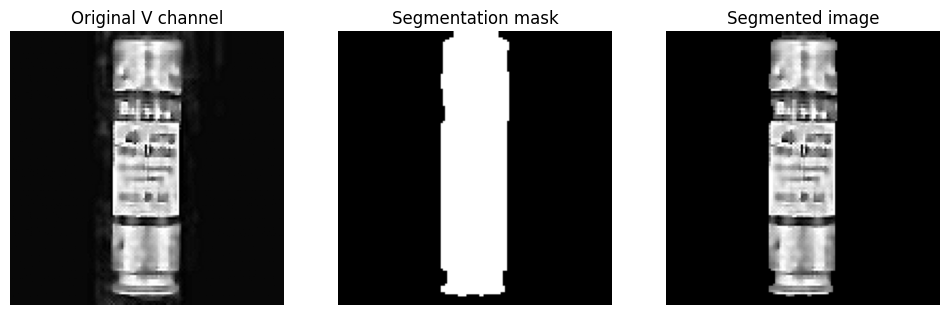

preprocessed shape:  (596, 128, 128)
Empty masks: 0
Min ratio: 0.033935546875
Max ratio: 1.0
Mean ratio: 0.32455751559878354
Foreground ratio: 0.148193359375
total:  596
failed:  0
segmented shape:  (596, 128, 128)
masks shape:  (596, 128, 128)
labels shape:  (596,)
After adaptive/combined thresholding ratio: 0.1646728515625
After closing ratio: 0.20269775390625
After opening ratio: 0.17608642578125
Final ratio: 0.148193359375


In [ ]:
idx = random.randint(0, len(segmented_images)-1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original V channel")
plt.imshow(preprocessed[idx], cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Segmentation mask")
plt.imshow(segmentation_masks[idx], cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Segmented image")
plt.imshow(segmented_images[idx], cmap="gray")
plt.axis("off")

plt.show()


preprocessed = np.array(preprocessed)
print("preprocessed shape: ",preprocessed.shape)


ratio = np.mean(final_mask > 0)
area_ratios = []
for mask in segmentation_masks:
    fg = np.sum(mask>0)
    total_mask = mask.size
    area_ratios.append(fg/total_mask)

area_ratios = np.array(area_ratios)
print("Empty masks:", np.sum(area_ratios==0))
print("Min ratio:", area_ratios.min())
print("Max ratio:", area_ratios.max())
print("Mean ratio:", area_ratios.mean())
print("Foreground ratio:", ratio)


print ("total: ", total)
print("failed: ",failed)
segmented_images = np.array(segmented_images)
segmentation_masks = np.array(segmentation_masks)

labels = np.array(labels)
print("segmented shape: ",segmented_images.shape)
print("masks shape: ",segmentation_masks.shape)

print("labels shape: ",labels.shape)


def debug_mask(m, name):
    print(name, "ratio:", np.mean(m > 0))



debug_mask(mask_thresh, "After adaptive/combined thresholding")
debug_mask(mask_close, "After closing")
debug_mask(mask_open, "After opening")
debug_mask(final_mask, "Final")






Feature Extraction

In [ ]:
def _features(img, mask):
    img = (img * 255).astype(np.uint8)


    _hog = hog(img, orientations=9, pixels_per_cell=(16, 16),
                       cells_per_block=(2, 2), visualize=False)


    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')

    (hist, _) = np.histogram(lbp[mask > 0].ravel(), bins=np.arange(0, 11), range=(0, 10))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)

    moments = cv.moments(mask)
    hu_moments = cv.HuMoments(moments).flatten()

    for i in range(0, 7):
        if hu_moments[i] != 0:
            hu_moments[i] = -1 * np.sign(hu_moments[i]) * np.log10(np.abs(hu_moments[i]))
        else:
            hu_moments[i] = 0

    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv.contourArea)
        area = cv.contourArea(cnt) / (128*128)
        perimeter = cv.arcLength(cnt, True) / 128
        x, y, w, h = cv.boundingRect(cnt)
        ar = float(w)/h if h > 0 else 0
        ar = min(ar, 10)
    else:
        area, perimeter, ar = 0, 0, 0


    return np.hstack([_hog, hist,hu_moments, [area, perimeter, ar]])


print("Extracting features")
features = []
for i in range(len(segmented_images)):
    feat = _features(segmented_images[i], segmentation_masks[i])
    features.append(feat)

X = np.array(features)
print("Feature matrix shape:", X.shape)

Extracting features
Feature matrix shape: (596, 1784)


In [ ]:
"""df = pd.read_csv('extracted_features.csv')
X = df.drop(columns=['label']).values
y = df['label'].values


model = joblib.load('electronic_component_svm_model.pkl')
scaler = joblib.load('scaler.pkl')
enc = joblib.load('encoder.pkl')

print("All components loaded. You can now run predictions!")"""

'df = pd.read_csv(\'extracted_features.csv\')\nX = df.drop(columns=[\'label\']).values\ny = df[\'label\'].values\n\n\nmodel = joblib.load(\'electronic_component_svm_model.pkl\')\nscaler = joblib.load(\'scaler.pkl\')\nenc = joblib.load(\'encoder.pkl\')\n\nprint("All components loaded. You can now run predictions!")'

Saving Features (CSV)

In [ ]:
df = pd.DataFrame(X)
df['label'] = labels
df.to_csv('extracted_features.csv', index=False)
print("Features saved to CSV.")

Features saved to CSV.


Model Training (SVM with RBF kernel)

In [ ]:
enc = LabelEncoder()
y = enc.fit_transform(labels)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Training SVM model")

model = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
model.fit(X_train, y_train)

Training SVM model


SVC(C=10, probability=True)

Saving Model

In [ ]:
joblib.dump(model, 'electronic_component_svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(enc, 'encoder.pkl')

print("Model and preprocessing objects saved successfully!")

Model and preprocessing objects saved successfully!


Loading the model and Features again

# Prediction and Accuracy Evaluation

Validation Data

Classification Report for Validation Data
                precision    recall  f1-score   support

      armature       0.62      0.68      0.65        22
cartridge-fuse       0.84      0.73      0.78        22
induction-coil       0.29      0.18      0.22        11
      rheostat       0.45      0.60      0.51        15
    transistor       0.95      0.95      0.95        19

      accuracy                           0.67        89
     macro avg       0.63      0.63      0.62        89
  weighted avg       0.68      0.67      0.67        89



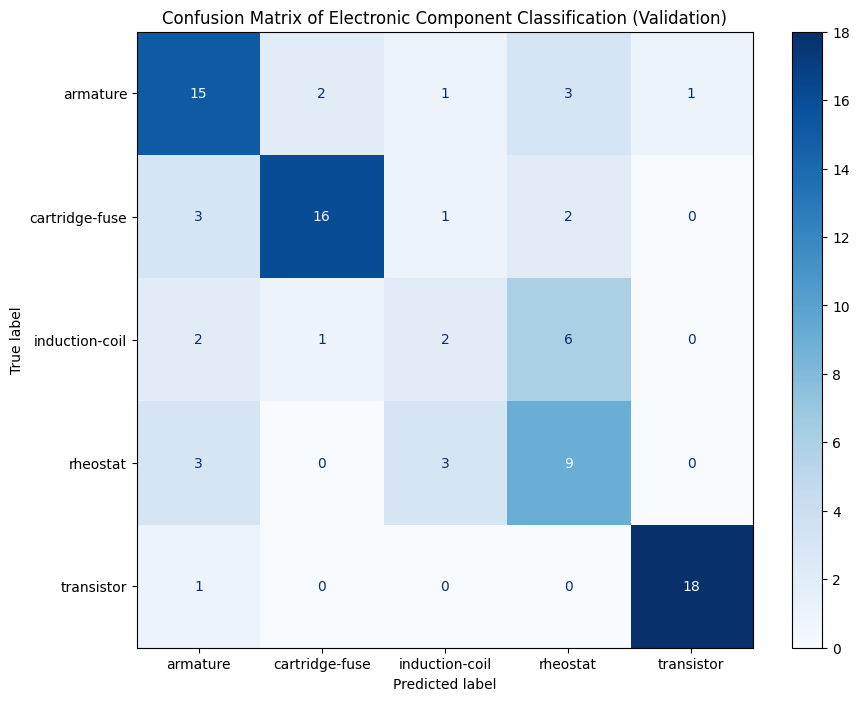

Overall Validation Accuracy: 67.42%


In [ ]:
y_pred_val = model.predict(X_val)


print("Classification Report for Validation Data")
print(classification_report(y_val, y_pred_val, target_names=enc.classes_))


fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(model, X_val, y_val,
                                      display_labels=enc.classes_,
                                      cmap='Blues', ax=ax)
plt.title("Confusion Matrix of Electronic Component Classification (Validation)")
plt.show()

accuracy = accuracy_score(y_val, y_pred_val)
print(f"Overall Validation Accuracy: {accuracy * 100:.2f}%")

Test Data

Classification Report for Testing Data
                precision    recall  f1-score   support

      armature       0.80      0.73      0.76        22
cartridge-fuse       0.83      0.83      0.83        23
induction-coil       0.50      0.36      0.42        11
      rheostat       0.61      0.79      0.69        14
    transistor       0.95      1.00      0.98        20

      accuracy                           0.78        90
     macro avg       0.74      0.74      0.73        90
  weighted avg       0.77      0.78      0.77        90



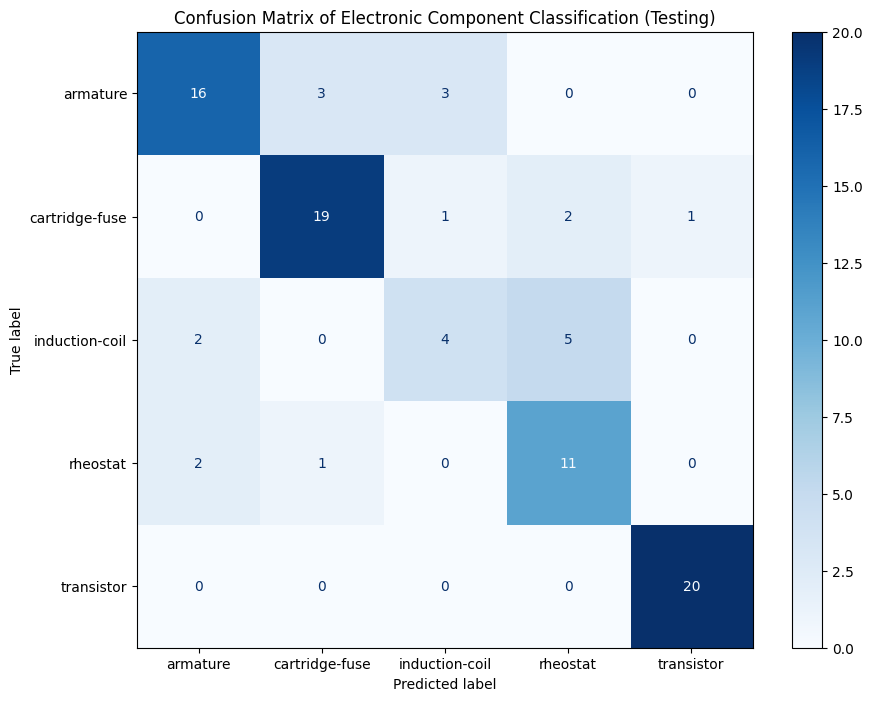

Overall Testing Accuracy: 77.78%


In [ ]:
y_pred = model.predict(X_test)


print("Classification Report for Testing Data")
print(classification_report(y_test, y_pred, target_names=enc.classes_))


fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
                                      display_labels=enc.classes_,
                                      cmap='Blues', ax=ax)
plt.title("Confusion Matrix of Electronic Component Classification (Testing)")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Testing Accuracy: {accuracy * 100:.2f}%")

Precision-Recall (PR) Curve

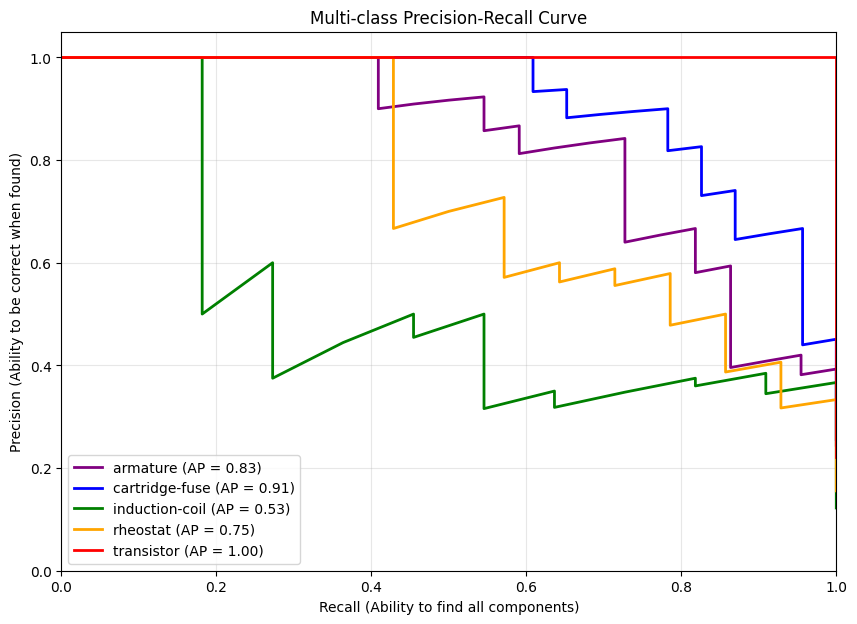

In [ ]:
y_test_binarized = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_binarized.shape[1]
y_score = model.predict_proba(X_test)


plt.figure(figsize=(10, 7))

colors = ['purple', 'blue', 'green', 'orange', 'red']
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_score[:, i])
    average_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])

    plt.plot(recall, precision, color=colors[i % len(colors)], lw=2,
             label=f'{enc.classes_[i]} (AP = {average_precision:.2f})')

plt.xlabel('Recall (Ability to find all components)')
plt.ylabel('Precision (Ability to be correct when found)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Multi-class Precision-Recall Curve')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()